In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded! ✅")

Libraries loaded! ✅


In [16]:
df = pd.read_csv('/kaggle/input/notebooks/sudhamag/preprocessing/preprocessed_data.csv')

X = df.drop('TARGET', axis=1)
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale pos weight
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)
xgb.fit(X_train, y_train)

print(f"Model retrained! ROC-AUC: {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.4f}")

Model retrained! ROC-AUC: 0.7577


In [17]:
print("Calculating SHAP values (this may take 2-3 minutes)...")

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test[:1000])  # use 1000 samples for speed

print("SHAP values calculated! ✅")
print("Shape of SHAP values:", shap_values.shape)

Calculating SHAP values (this may take 2-3 minutes)...
SHAP values calculated! ✅
Shape of SHAP values: (1000, 125)


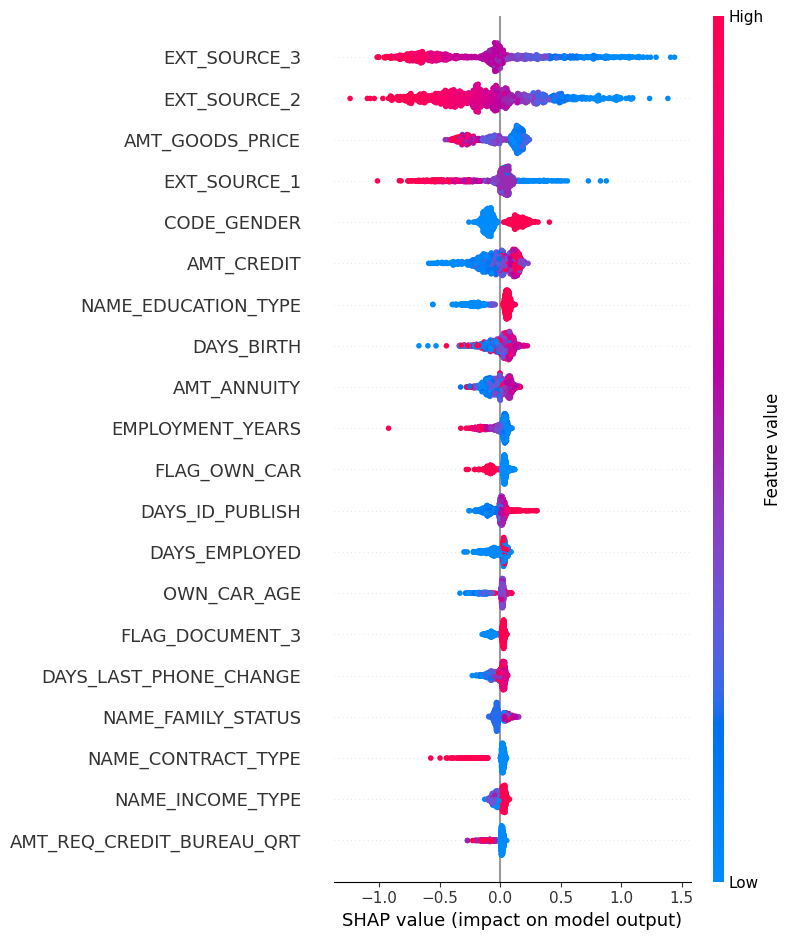

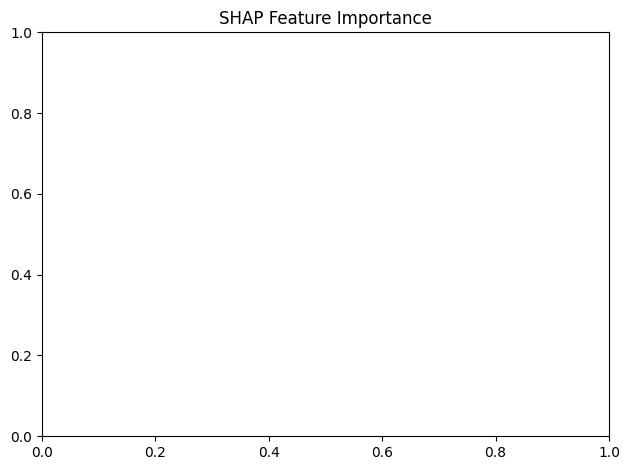

In [18]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test[:1000],
    max_display=20,
    show=True
)
plt.title("SHAP Feature Importance")
plt.tight_layout()

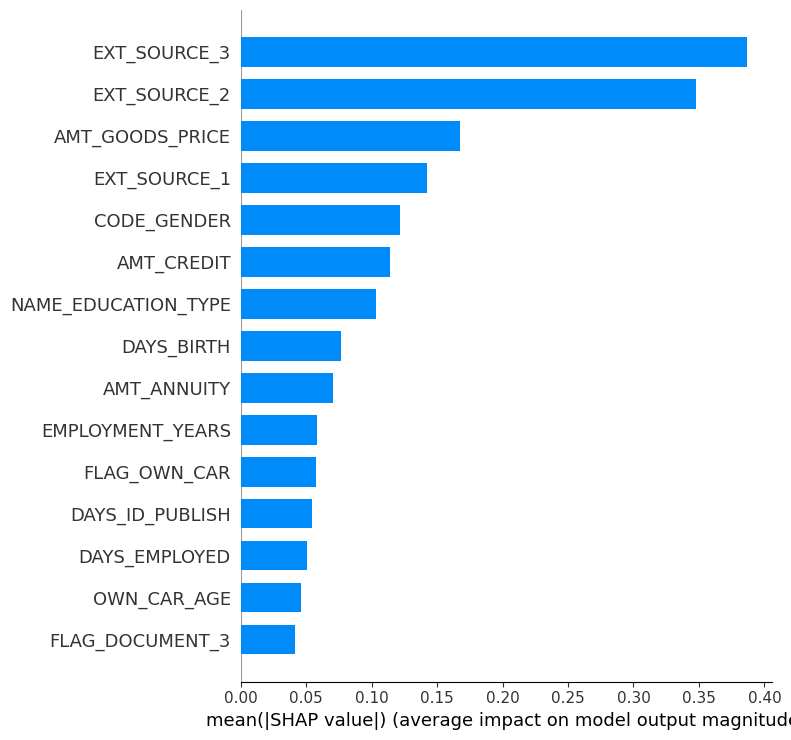

In [19]:
shap.summary_plot(
    shap_values,
    X_test[:1000],
    plot_type='bar',
    max_display=15,
    show=True
)

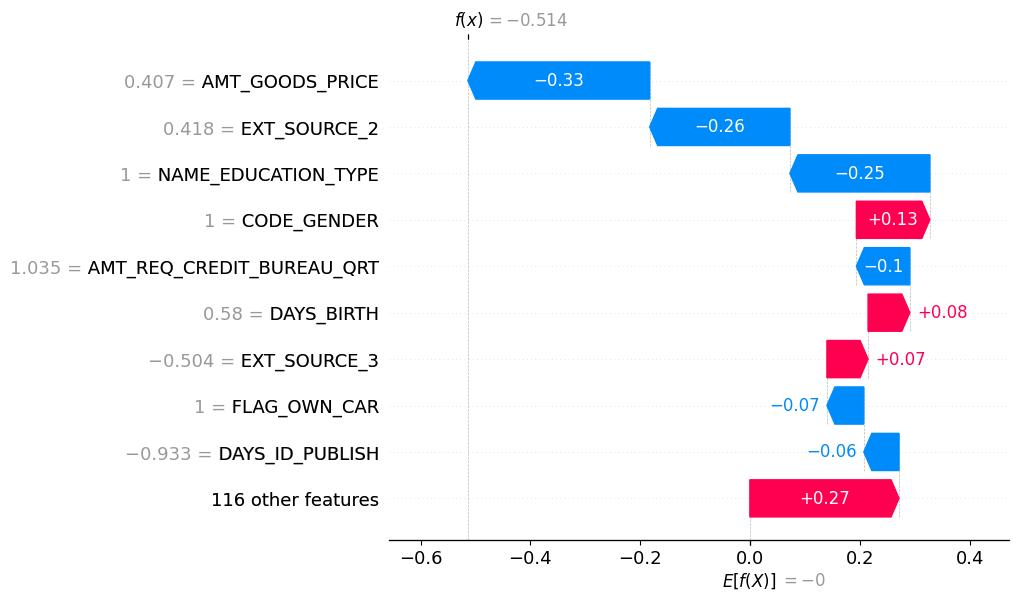

In [20]:
# Explain a single prediction
sample_idx = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_idx],
        feature_names=X_test.columns.tolist()
    )
)

Top feature: EXT_SOURCE_3


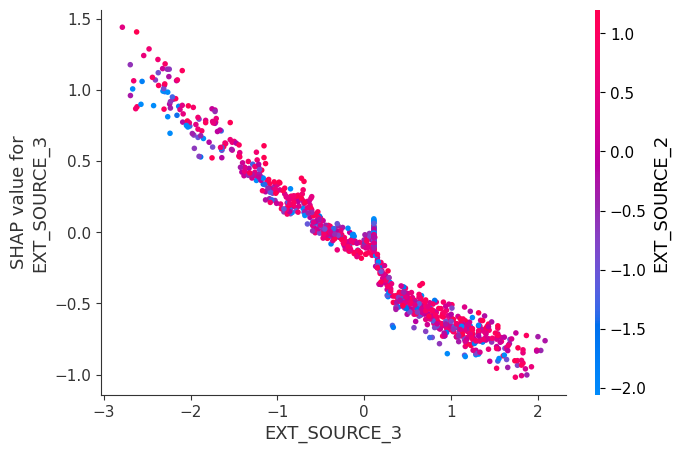

In [21]:
# Top feature impact
top_feature = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).idxmax()

print(f"Top feature: {top_feature}")

shap.dependence_plot(
    top_feature,
    shap_values,
    X_test[:1000],
    show=True
)

In [22]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Default', 'Default'],
    mode='classification'
)

print("LIME explainer ready! ✅")

LIME explainer ready! ✅


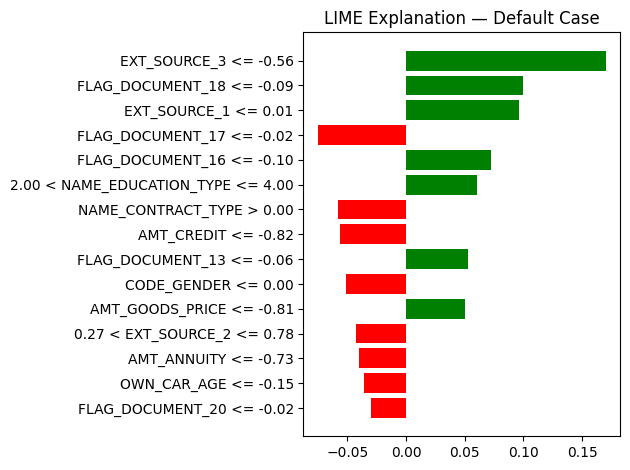

LIME explanation complete! ✅


In [23]:
# Pick a defaulter from test set
default_idx = np.where(y_test.values == 1)[0][0]

lime_exp = lime_explainer.explain_instance(
    data_row=X_test.values[default_idx],
    predict_fn=xgb.predict_proba,
    num_features=15
)

lime_exp.as_pyplot_figure()
plt.title("LIME Explanation — Default Case")
plt.tight_layout()
plt.show()

print("LIME explanation complete! ✅")

In [24]:
# Top SHAP features
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False).head(10)

# Top LIME features
lime_features = pd.DataFrame(
    lime_exp.as_list(),
    columns=['Feature', 'LIME Score']
).head(10)

print("=== Top 10 SHAP Features ===")
print(shap_importance.to_string())
print("\n=== Top 10 LIME Features ===")
print(lime_features.to_string(index=False))
print("\nExplainability Complete! ✅")

=== Top 10 SHAP Features ===
EXT_SOURCE_3           0.386488
EXT_SOURCE_2           0.347886
AMT_GOODS_PRICE        0.167621
EXT_SOURCE_1           0.142445
CODE_GENDER            0.121633
AMT_CREDIT             0.114263
NAME_EDUCATION_TYPE    0.103583
DAYS_BIRTH             0.076306
AMT_ANNUITY            0.070817
EMPLOYMENT_YEARS       0.058183

=== Top 10 LIME Features ===
                           Feature  LIME Score
             EXT_SOURCE_3 <= -0.56    0.170113
         FLAG_DOCUMENT_18 <= -0.09    0.099498
              EXT_SOURCE_1 <= 0.01    0.096715
         FLAG_DOCUMENT_17 <= -0.02   -0.075146
         FLAG_DOCUMENT_16 <= -0.10    0.072273
2.00 < NAME_EDUCATION_TYPE <= 4.00    0.060218
         NAME_CONTRACT_TYPE > 0.00   -0.057932
               AMT_CREDIT <= -0.82   -0.056466
         FLAG_DOCUMENT_13 <= -0.06    0.052888
               CODE_GENDER <= 0.00   -0.050916

Explainability Complete! ✅
